# Model-Comparsion

This section aims at 
+ loading all the output coming from running python script in the terminal 
+ giving detailed comparisons of model perfromances and stability analysis.

## Loading cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
# theme setting 
def set_ggplot_theme():
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)

    plt.rcParams.update({
        "figure.figsize": (6.5, 4.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,

        # --- fonts: match LaTeX-like serif ---
        "font.family": "serif",
        "font.serif": ["Times", "STIXGeneral"],
        "mathtext.fontset": "cm",
        "text.usetex": False,


        "axes.edgecolor": "0.2",
        "axes.linewidth": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",

        "grid.color": "#e6e6e6",
        "grid.linewidth": 1,
        "grid.alpha": 0.8,

        "legend.frameon": False,
        "xtick.color": "0.2",
        "ytick.color": "0.2",


        # fonts
        "font.size": 10,          # base size
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,

        # make titles not overpower text
        "axes.titleweight": "semibold",
    })

set_ggplot_theme()
COLORS = {
    "risk": "#B22222",
    "ct": "#2C7FB8",
    "gap": "#7A5195",
    "neutral": "#6E6E6E"
}

AGE_PALETTE = sns.color_palette("viridis", 5)
HEATMAP_CMAP = sns.color_palette("rocket_r", as_cmap=True)

In [3]:
# %run clean.py

In [4]:
cleaned_data = pd.read_csv('../data/TBI_cleaned.csv')

## Load performance

In [5]:
# %run models.py

In [6]:
metrics_data = pd.read_csv('../others/model_performance.csv')

## Performance

### Age < 2

In [7]:
metrics_data.query("age_group == 'Age < 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])

,model,age_group,threshold,split,Sensitivity,Specificity,NPV,ROC_AUC,PR_AUC,Precision,TP,FN,TN,FP,n,pos
2,CDR,Age < 2,NaN,test,1.000000,0.541902,1.000000,NaN,NaN,0.019153,19,0,1151,973,2143,19
14,CatBoost,Age < 2,0.20,test,0.833333,0.667907,0.996530,0.854349,0.388225,0.033829,25,5,1436,714,2180,30
8,Logistic Regression,Age < 2,0.02,test,0.800000,0.707965,0.996068,0.841624,0.261193,0.036866,24,6,1520,627,2177,30
12,CatBoost,Age < 2,0.20,train,1.000000,0.657982,1.000000,0.961908,0.526818,0.040283,108,0,4950,2573,7631,108
0,CDR,Age < 2,NaN,train,0.985507,0.537799,0.999750,NaN,NaN,0.019406,68,1,3998,3436,7503,69
6,Logistic Regression,Age < 2,0.02,train,0.933962,0.708849,0.998688,0.932160,0.368515,0.043288,99,7,5327,2188,7621,106
1,CDR,Age < 2,NaN,val,1.000000,0.544256,1.000000,NaN,NaN,0.020243,10,0,578,484,1072,10
7,Logistic Regression,Age < 2,0.02,val,1.000000,0.722533,1.000000,0.936468,0.283121,0.047923,15,0,776,298,1089,15
13,CatBoost,Age < 2,0.20,val,0.933333,0.690233,0.998654,0.943318,0.388783,0.040346,14,1,742,333,1090,15


**Conclusion:**

Let us compare the three models' performance on test sets and focus on the the same metrics as Kuppermann etal.
+ Sensitivity
+ Negative Predictive Value

As for the negative predictive values, they all have very similar results at around 99\%. 
As for the sensitivity, the other two models perform worse compared with CDR. They all miss some positive samples which in the clinical world, it's terrible.

When I trained my own models, I did the hyperparameter tuning based on the balance of sensitivity and specificity to avoid overfitting on the extremely imbalanced data. This is can be one reason why my own models does a worse job.

### Age >= 2

In [8]:
metrics_data.query("age_group == 'Age >= 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])

,model,age_group,threshold,split,Sensitivity,Specificity,NPV,ROC_AUC,PR_AUC,Precision,TP,FN,TN,FP,n,pos
17,CatBoost,Age >= 2,0.2,test,0.983607,0.759649,0.999587,0.965010,0.563947,0.072639,120,2,4842,1532,6496,122
5,CDR,Age >= 2,NaN,test,0.964286,0.582591,0.999454,NaN,NaN,0.020172,54,2,3661,2623,6340,56
11,Logistic Regression,Age >= 2,0.1,test,0.769231,0.933124,0.995478,0.941659,0.378876,0.174419,90,27,5944,426,6487,117
15,CatBoost,Age >= 2,0.2,train,0.981265,0.757296,0.999527,0.964119,0.584223,0.071833,419,8,16893,5414,22734,427
3,CDR,Age >= 2,NaN,train,0.969072,0.575398,0.999526,NaN,NaN,0.019738,188,6,12653,9337,22184,194
9,Logistic Regression,Age >= 2,0.1,train,0.728814,0.926815,0.994607,0.936191,0.383535,0.155797,301,112,20655,1631,22699,413
16,CatBoost,Age >= 2,0.2,val,0.967213,0.755883,0.999170,0.963854,0.644056,0.070490,59,2,2409,778,3248,61
4,CDR,Age >= 2,NaN,val,0.964286,0.581477,0.999453,NaN,NaN,0.020119,27,1,1827,1315,3170,28
10,Logistic Regression,Age >= 2,0.1,val,0.810345,0.928078,0.996291,0.950003,0.407577,0.170290,47,11,2955,229,3242,58


**Conclusion:**

Things change in the case of group aged at 2 and older, as for the sensitivity: CatBoost > CDR > Logistic Regression

One explanation is that we have around 75\% of our raw data come from the age >= 2 group. For complex models, more data means they can learn more nonlinear patterns at the scarifice of interpretability.

## Interpretability

### Age < 2

I just focus on the logistic regression and catboost, since the decision rule will no doubt have the top intepretability among the three, even all the machine learning models.

In [9]:
# logsitic regression coefficients
lr_coeff = pd.read_csv('../others/lr_coefficients.csv')
lr_coeff.head()

,model,age_group,feature,coef,abs_coef
0,Logistic Regression,Age < 2,Seiz,18.713015,18.713015
1,Logistic Regression,Age < 2,NeuroD_missing,14.625928,14.625928
2,Logistic Regression,Age < 2,GCSEye,-9.219562,9.219562
3,Logistic Regression,Age < 2,ClavOcc_1,9.018224,9.018224
4,Logistic Regression,Age < 2,GCSVerbal,-8.105043,8.105043


In [10]:
lr_coeff.query("age_group == 'Age < 2'").sort_values(by = ['abs_coef'], ascending = [False]).head(15)

,model,age_group,feature,coef,abs_coef
0,Logistic Regression,Age < 2,Seiz,18.713015,18.713015
1,Logistic Regression,Age < 2,NeuroD_missing,14.625928,14.625928
2,Logistic Regression,Age < 2,GCSEye,-9.219562,9.219562
3,Logistic Regression,Age < 2,ClavOcc_1,9.018224,9.018224
4,Logistic Regression,Age < 2,GCSVerbal,-8.105043,8.105043
5,Logistic Regression,Age < 2,LOCSeparate_missing,8.088586,8.088586
6,Logistic Regression,Age < 2,HemaLoc_3.0,7.597902,7.597902
7,Logistic Regression,Age < 2,GCSMotor,6.256959,6.256959
8,Logistic Regression,Age < 2,SFxPalp_2.0,5.852919,5.852919
9,Logistic Regression,Age < 2,ActNorm,-5.848910,5.848910


**Remark:**
we examined the magnitude and direction of the logistic regression coefficients selected after feature selection. Because logistic regression models the log-odds of clinically important traumatic brain injury (ciTBI), positive coefficients indicate increased risk while negative coefficients indicate protective or low-risk signals.

Different from the CDR model, we include the GCS componet `GCSEye`, `GCSVerbal` and `GCSMotor` in our model. The first two have large and negative coefficients in our model, indicating that higher neurologic function strongly reduces predicted risk, consistent with established clinical knowledge. While for `GCSMotor`, it has positive coefficient, which is contrary to our clinical knowlegde. It looks like things become more complicated when it comes to motor part.

Conversely, altered mental status, seizure, severe injury mechanism, and signs suggestive of skull fracture are associated with increased risk, reflecting patterns emphasized in the PECARN decision rule.

Interestingly, several missingness indicators also appear among the influential features. Rather than behaving as random noise, missing clinical assessments are associated with elevated predicted risk. This likely reflects real-world emergency department workflow, where incomplete documentation often occurs in more severe or unstable patients, suggesting that missingness itself carries clinical information.

In [11]:
# catboost feature importance
catboost_importance = pd.read_csv('../others/catboost_feature_importances.csv')
catboost_importance.head()

,model,age_group,feature,importance
0,CatBoost,Age < 2,LOCSeparate,16.304152
1,CatBoost,Age < 2,HemaLoc,7.736420
2,CatBoost,Age < 2,AMS,7.695095
3,CatBoost,Age < 2,SFxPalp,7.037532
4,CatBoost,Age < 2,ActNorm,6.648683


In [12]:
catboost_importance.query("age_group == 'Age < 2'").sort_values(by = ['importance'], ascending = [False]).head(15)

,model,age_group,feature,importance
0,CatBoost,Age < 2,LOCSeparate,16.304152
1,CatBoost,Age < 2,HemaLoc,7.736420
2,CatBoost,Age < 2,AMS,7.695095
3,CatBoost,Age < 2,SFxPalp,7.037532
4,CatBoost,Age < 2,ActNorm,6.648683
5,CatBoost,Age < 2,GCSTotal,5.334597
6,CatBoost,Age < 2,AMSOth,5.098545
7,CatBoost,Age < 2,AMSSlow,3.818360
8,CatBoost,Age < 2,ClavNeck,3.654000
9,CatBoost,Age < 2,GCSVerbal,3.508900


**Remark:**

All of the six predictors in the CDR model have been included in the catboost model and rank very high.

Since we include GCS 3-13 in our data, `GCSTotal` carries a lot of predictive ability.

Without using the shapley values, we cannot tell the direction of how each features influence our decision.

### Age >=2

In [13]:
lr_coeff.query("age_group == 'Age >= 2'").sort_values(by = ['abs_coef'], ascending = [False]).head(15)

,model,age_group,feature,coef,abs_coef
18,Logistic Regression,Age >= 2,GCSGroup,-18.259415,18.259415
19,Logistic Regression,Age >= 2,SFxBas,16.214518,16.214518
20,Logistic Regression,Age >= 2,NeuroD,13.955233,13.955233
21,Logistic Regression,Age >= 2,AMS,11.908855,11.908855
22,Logistic Regression,Age >= 2,LocLen_missing,11.110353,11.110353
23,Logistic Regression,Age >= 2,VomitStart_3.0,10.424298,10.424298
24,Logistic Regression,Age >= 2,ActNorm,-10.420273,10.420273
25,Logistic Regression,Age >= 2,HAStart_3.0,-8.653041,8.653041
26,Logistic Regression,Age >= 2,ClavPar_1,7.724138,7.724138
27,Logistic Regression,Age >= 2,OSIOth_1,7.686336,7.686336


**Remark:**

For children aged ≥2 years, the logistic regression model identifies clinically meaningful predictors that align closely with established traumatic brain injury risk factors. 

The strongest positive associations with ciTBI risk include signs of basilar skull fracture (SFxBas), neurological deficit (NeuroD), altered mental status (AMS), severe headache (HASeverity), and high-impact injury mechanisms, all of which are consistent with known high-risk clinical indicators. 

Lower Glasgow Coma Scale status (GCSGroup) shows a strong negative coefficient, indicating that better neurological status substantially reduces predicted risk. It is consistent with CDR modeling, GCSGroup =1 for GCS 3-13, GCSGroup =2 for GCS 14-15.

Several missingness indicators (e.g., Dizzy_missing, LOCSeparate_missing, LocLen_missing) also carry positive coefficients, suggesting that incomplete assessments themselves may reflect higher clinical concern or workflow-driven selective documentation. 

In [14]:
catboost_importance.query("age_group == 'Age >= 2'").sort_values(by = ['importance'], ascending = [False]).head(15)

,model,age_group,feature,importance
50,CatBoost,Age >= 2,AMS,9.731539
51,CatBoost,Age >= 2,ActNorm,9.381688
52,CatBoost,Age >= 2,LOCSeparate,8.946638
53,CatBoost,Age >= 2,AMSRepeat,6.693282
54,CatBoost,Age >= 2,AMSSlow,4.853074
55,CatBoost,Age >= 2,Amnesia_verb,4.704916
56,CatBoost,Age >= 2,High_impact_InjSev,4.190617
57,CatBoost,Age >= 2,HA_verb,3.364001
58,CatBoost,Age >= 2,InjuryMech,3.166005
59,CatBoost,Age >= 2,LocLen,3.132708


**Remark:**

Compared with the CDR for group aged at two and older, we still have altered mental status, severe injury mechanism, severe headache and loss of consciousness among the most important features.

But, we don't see vomit and basilar skull fracture signs in the top 15 features, which is surprising. 

Meanwhile, trauma above the clavicles appear in the important features, both of which CDR don't include in both age group rule.

### Presentations

In [15]:
topK = 10
# age < 2 
lr_coef_age2mius_topk = (
    lr_coeff.query("age_group == 'Age < 2'").
    sort_values(by = ['abs_coef'], ascending = [False]).head(topK)
)

cat_imp_age2mius_topk = (
catboost_importance.query("age_group == 'Age < 2'").
sort_values(by = ['importance'], ascending = [False]).head(topK)
)

In [16]:
# age >= 2

lr_coef_age2plus_topk = (
    lr_coeff.query("age_group == 'Age >= 2'").
    sort_values(by = ['abs_coef'], ascending = [False]).head(topK)
)

cat_imp_age2plus_topk = (
catboost_importance.query("age_group == 'Age >= 2'").
sort_values(by = ['importance'], ascending = [False]).head(topK)
)

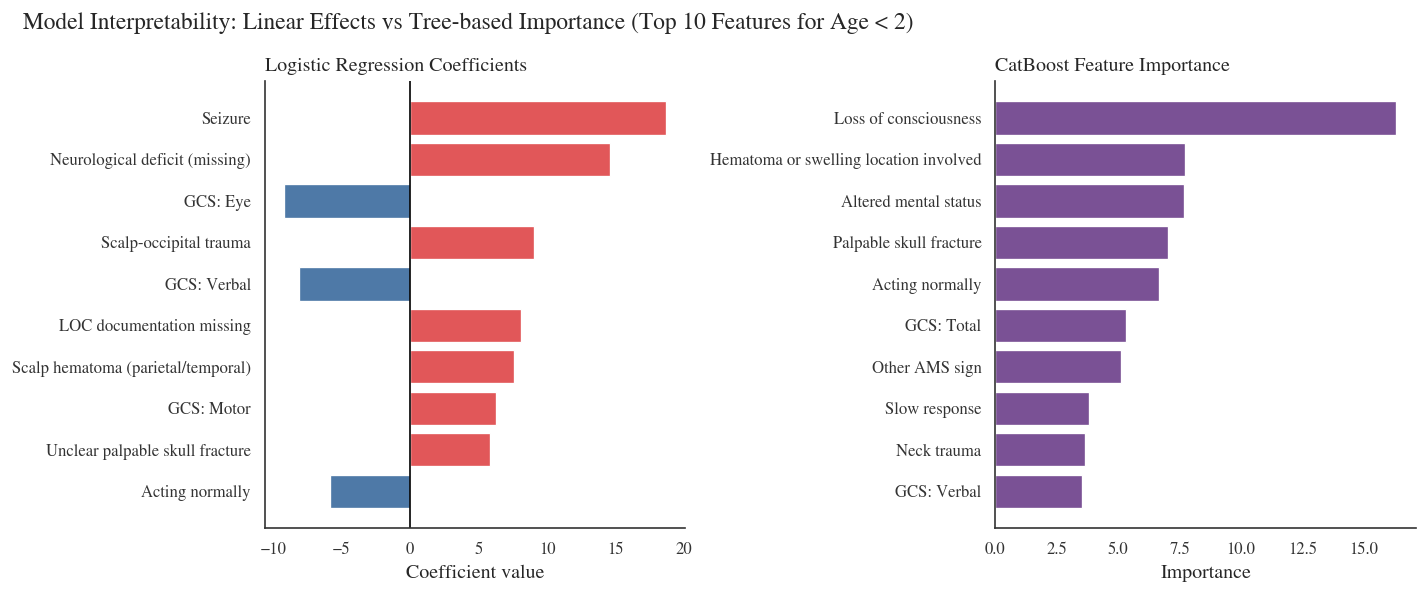

In [17]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12,5),
    gridspec_kw={"width_ratios":[1,1]}
)
FEATURE_NAME_MAP = {
    # symptoms
    "Seiz": "Seizure",
    "AMS": "Altered mental status",
    "ActNorm": "Acting normally",
    "LOCSeparate": "Loss of consciousness",

    # missingness indicators
    "NeuroD_missing": "Neurological deficit (missing)",
    "LOCSeparate_missing": "LOC documentation missing",

    # exam findings
    "HemaLoc_3.0": "Scalp hematoma (parietal/temporal)",
    "SFxPalp_2.0": "Unclear palpable skull fracture",
    "ClavOcc_1": "Scalp-occipital trauma",
    "ClavNeck": "Neck trauma",
    'SFxPalp': "Palpable skull fracture",
    "HemaLoc": "Hematoma or swelling location involved",

    # GCS
    "GCSEye": "GCS: Eye",
    "GCSVerbal": "GCS: Verbal",
    "GCSMotor": "GCS: Motor",
    "GCSTotal": "GCS: Total",

    # derived
    "AMSOth": "Other AMS sign",
    "AMSSlow": "Slow response"
}

lr_coef_age2mius_topk["feature_plot"] = lr_coef_age2mius_topk["feature"].map(
    FEATURE_NAME_MAP
).fillna(lr_coef_age2mius_topk["feature"])

cat_imp_age2mius_topk["feature_plot"] = cat_imp_age2mius_topk["feature"].map(
    FEATURE_NAME_MAP
).fillna(cat_imp_age2mius_topk["feature"])

# -------------------------
# LEFT: Logistic Regression
# -------------------------
ax = axes[0]

colors = lr_coef_age2mius_topk["coef"].apply(
    lambda x: "#E15759" if x > 0 else "#4E79A7"
)

ax.barh(
    lr_coef_age2mius_topk["feature_plot"],
    lr_coef_age2mius_topk["coef"],
    color=colors
)

ax.axvline(0, color="black", lw=1)

ax.set_title("Logistic Regression Coefficients", loc="left", weight="bold")
ax.set_xlabel("Coefficient value")
ax.invert_yaxis()
ax.grid(False)
sns.despine(ax=ax)

# -------------------------
# RIGHT: CatBoost importance
# -------------------------
ax = axes[1]

ax.barh(
    cat_imp_age2mius_topk["feature_plot"],
    cat_imp_age2mius_topk["importance"],
    color="#7A5195"
)

ax.set_title("CatBoost Feature Importance", loc="left", weight="bold")
ax.set_xlabel("Importance")
ax.invert_yaxis()
ax.grid(False)
sns.despine(ax=ax)

# -------------------------
fig.suptitle(
    "Model Interpretability: Linear Effects vs Tree-based Importance (Top 10 Features for Age < 2)",
    x=0.02,
    ha="left",
    fontsize=14,
    weight="normal"
)

plt.tight_layout()
plt.savefig("../figs/model_interpretability_age2mius.png", dpi=300)
plt.show()

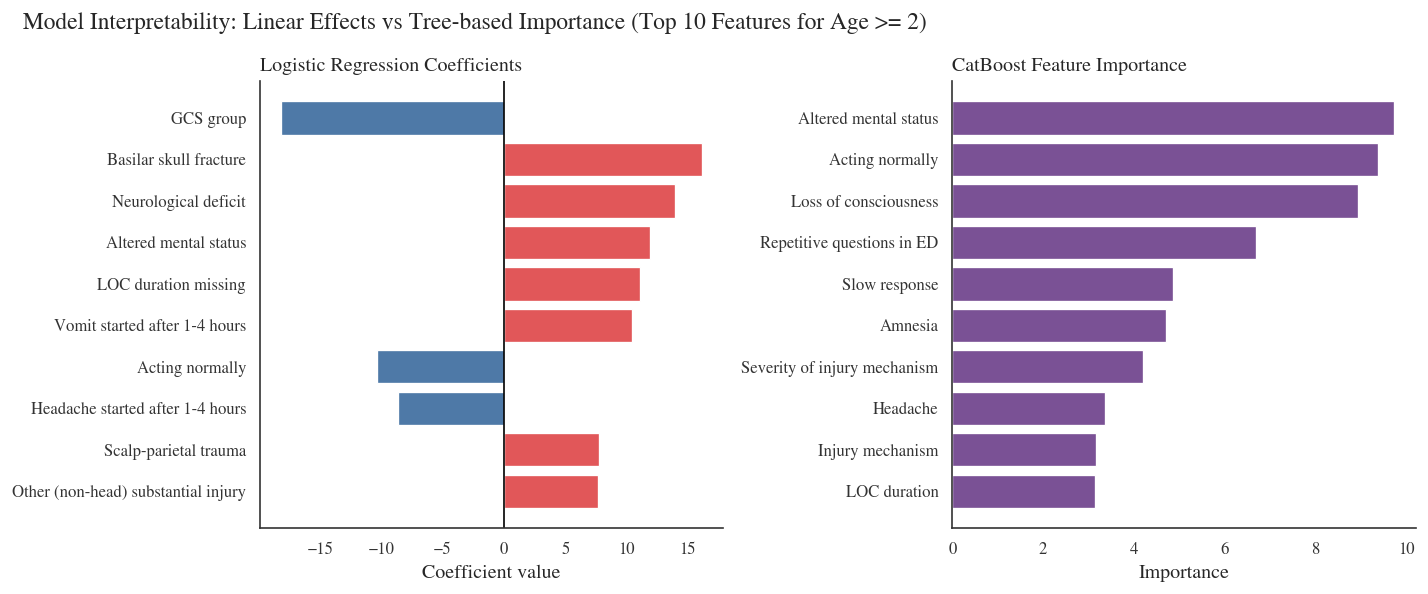

In [18]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12,5),
    gridspec_kw={"width_ratios":[1,1]}
)
FEATURE_NAME_MAP = {
    # symptoms
    "Seiz": "Seizure",
    "AMS": "Altered mental status",
    "ActNorm": "Acting normally",
    "LOCSeparate": "Loss of consciousness",
    'LocLen': "LOC duration",
    'InjuryMech': "Injury mechanism",
    "Amnesia_verb": "Amnesia",
    "High_impact_InjSev": "Severity of injury mechanism",
    'HA_verb': "Headache",

    # missingness indicators
    "NeuroD_missing": "Neurological deficit (missing)",
    "LOCSeparate_missing": "LOC documentation missing",
    'LocLen_missing': "LOC duration missing",

    # exam findings
    "HemaLoc_3.0": "Scalp hematoma (parietal/temporal)",
    "SFxPalp_2.0": "Unclear palpable skull fracture",
    "ClavOcc_1": "Scalp-occipital trauma",
    "ClavNeck": "Neck trauma",
    'SFxPalp': "Palpable skull fracture",
    "HemaLoc": "Hematoma or swelling location involved",
    'VomitStart_3.0': "Vomit started after 1-4 hours",
    'HAStart_3.0': "Headache started after 1-4 hours",
    'ClavPar_1': "Scalp-parietal trauma",
    'OSIOth_1': "Other (non-head) substantial injury",
    "AMSRepeat": "Repetitive questions in ED",

    # GCS
    "GCSEye": "GCS: Eye",
    "GCSVerbal": "GCS: Verbal",
    "GCSMotor": "GCS: Motor",
    "GCSTotal": "GCS: Total",
    'GCSGroup': "GCS group",

    # derived
    "AMSOth": "Other AMS sign",
    "AMSSlow": "Slow response",

    'NeuroD': "Neurological deficit",
    'SFxBas': "Basilar skull fracture",

}

lr_coef_age2plus_topk["feature_plot"] = lr_coef_age2plus_topk["feature"].map(
    FEATURE_NAME_MAP
).fillna(lr_coef_age2plus_topk["feature"])

cat_imp_age2plus_topk["feature_plot"] = cat_imp_age2plus_topk["feature"].map(
    FEATURE_NAME_MAP
).fillna(cat_imp_age2plus_topk["feature"])

# -------------------------
# LEFT: Logistic Regression
# -------------------------
ax = axes[0]

colors = lr_coef_age2plus_topk["coef"].apply(
    lambda x: "#E15759" if x > 0 else "#4E79A7"
)

ax.barh(
    lr_coef_age2plus_topk["feature_plot"],
    lr_coef_age2plus_topk["coef"],
    color=colors
)

ax.axvline(0, color="black", lw=1)

ax.set_title("Logistic Regression Coefficients", loc="left", weight="bold")
ax.set_xlabel("Coefficient value")
ax.invert_yaxis()
ax.grid(False)
sns.despine(ax=ax)

# -------------------------
# RIGHT: CatBoost importance
# -------------------------
ax = axes[1]

ax.barh(
    cat_imp_age2plus_topk["feature_plot"],
    cat_imp_age2plus_topk["importance"],
    color="#7A5195"
)

ax.set_title("CatBoost Feature Importance", loc="left", weight="bold")
ax.set_xlabel("Importance")
ax.invert_yaxis()
ax.grid(False)
sns.despine(ax=ax)

# -------------------------
fig.suptitle(
    "Model Interpretability: Linear Effects vs Tree-based Importance (Top 10 Features for Age >= 2)",
    x=0.02,
    ha="left",
    fontsize=14,
    weight="normal"
)

plt.tight_layout()
plt.savefig("../figs/model_interpretability_age2plus.png", dpi=300)
plt.show()

## Stability

In this subsection, I test the stability of the three models in the case of data pertubation and change of my judgment call.

### CDR

Because the clinical decision rule is fixed (not trained), we assessed stability via a perturbation analysis that mimics plausible charting noise in manually collected clinical variables. 

Specifically, several subjective binary predictors used in the rule (e.g., altered mental status, vomiting, basilar skull fracture signs, and acting normally per parent) were randomly perturbed. In each simulation, 5% of observed binary values were flipped (0↔1), mimicking realistic variability arising from documentation differences or inter-observer assessment. Missing values were left unchanged to preserve the original data structure. This perturbation procedure was repeated 100 times on the validation dataset, and performance metrics were recomputed after each perturbation.

In [19]:
# cdr stability analysis
cdr_stability = pd.read_csv('../others/cdr_rule_perturbation_stability.csv')
cdr_stability.head()

,model,split,age_group,rep,sensitivity,specificity,npv
0,CDR,train,<2,0,0.985507,0.487086,0.999724
1,CDR,train,<2,1,0.971014,0.487086,0.999448
2,CDR,train,<2,2,0.985507,0.490718,0.999726
3,CDR,train,<2,3,0.971014,0.486817,0.999448
4,CDR,train,<2,4,0.985507,0.494216,0.999728


In [20]:
cdr_stability_age2minus = cdr_stability.query("age_group == '<2'")[['rep', 'sensitivity', 'npv','specificity']]

In [21]:
cdr_stability_age2minus.agg(["mean", "std", "min", "max"])

,rep,sensitivity,npv,specificity
mean,24.500000,0.994274,0.999892,0.493125
std,14.479214,0.010002,0.000186,0.005613
min,0.000000,0.947368,0.999049,0.477401
max,49.000000,1.000000,1.000000,0.516008


In [22]:
cdr_stability_age2minus.quantile([0.025, 0.5, 0.975])

,rep,sensitivity,npv,specificity
0.025,1.0,0.971014,0.999449,0.484204
0.500,24.5,1.000000,1.000000,0.492467
0.975,48.0,1.000000,1.000000,0.504025


In [23]:
cdr_stability_age2plus = cdr_stability.query("age_group == '>=2'")[['rep', 'sensitivity', 'npv','specificity']]

In [24]:
cdr_stability_age2plus.agg(["mean", "std", "min", "max"])

,rep,sensitivity,npv,specificity
mean,24.500000,0.965214,0.999387,0.503598
std,14.479214,0.013736,0.000242,0.004636
min,0.000000,0.928571,0.998717,0.492680
max,49.000000,1.000000,1.000000,0.514004


In [25]:
cdr_stability_age2plus.quantile([0.025, 0.5, 0.975])

,rep,sensitivity,npv,specificity
0.025,1.0,0.928571,0.998753,0.496583
0.500,24.5,0.964286,0.999370,0.503501
0.975,48.0,1.000000,1.000000,0.511951


**Remark:**

Across simulations, the rule demonstrated strong stability in both age groups. In the age < 2 group, sensitivity remained consistently high, with a median value of 1.00 and a narrow range spanning roughly 0.97 to 1.00. Specificity showed only modest variation, centered around 0.50, while negative predictive value (NPV) remained extremely high and nearly invariant (≈0.999–1.000).

The conclusion holds true for age >=2 group. The difference is that the sensitivity is a little bit lower than age under 2, with a median value of 0.97.


These results indicate that the clinical decision rule is robust to small perturbations in input features and that its safety-critical property — maintaining high sensitivity and NPV — is not driven by fragile or unstable measurements. Minor changes in subjective clinical inputs primarily affect specificity rather than the ability of the rule to identify patients at risk.

Overall, the perturbation analysis supports that the decision rule’s performance is structurally stable and unlikely to change substantially under reasonable variations in clinical assessment.

### Logsitic Regression

One judgment call in the logistic regression modeling was imputing missing Glasgow Coma Scale (GCS) components using clinically informed rules. Because GCS variables are central predictors, we evaluated whether model performance depended on this assumption.

To test stability, we repeated the entire modeling procedure under a stricter scenario where all observations with missing GCS components were removed instead of imputed. The same feature set, training procedure, and evaluation metrics were used.

Model performance was then compared between:

+ Imputed dataset (primary analysis)
+ Complete-case dataset (no GCS imputation)

Consistent performance across the two settings indicates that the selected predictors and model conclusions are robust to the GCS imputation strategy.

In [26]:
# lr stability analysis
lr_stability = pd.read_csv('../others/lr_perturbation_stability.csv')
lr_stability.head()

,model,age_group,threshold,split,Sensitivity,Specificity,NPV,ROC_AUC,PR_AUC,Precision,TP,FN,TN,FP,n,pos
0,Logistic Regression,Age < 2,0.02,train,0.922330,0.740475,0.998511,0.928793,0.297830,0.048101,95,8,5364,1880,7347,103
1,Logistic Regression,Age < 2,0.02,val,1.000000,0.761673,1.000000,0.928165,0.142251,0.050388,13,0,783,245,1041,13
2,Logistic Regression,Age < 2,0.02,test,0.766667,0.749159,0.995530,0.856311,0.240817,0.042202,23,7,1559,522,2111,30
3,Logistic Regression,Age >= 2,0.10,train,0.900249,0.757941,0.997569,0.919480,0.247403,0.064418,361,40,16417,5243,22061,401
4,Logistic Regression,Age >= 2,0.10,val,0.875000,0.767442,0.997063,0.909370,0.230675,0.063719,49,7,2376,720,3152,56


In [27]:
lr_stability_age2minus = lr_stability.query("age_group == 'Age < 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])

In [28]:
lr_origin_age2minus = metrics_data.query("model == 'Logistic Regression' and age_group == 'Age < 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])

In [29]:
lr_stability_age2minus['source'] = 'perturbation'
lr_origin_age2minus['source'] = 'original'
pd.concat([lr_stability_age2minus, lr_origin_age2minus], ignore_index = True).sort_values(by = ['split', 'source','Sensitivity' ,'NPV'], ascending = [True, True,False, False])[['split', 'source', 'Sensitivity', 'NPV']]

,split,source,Sensitivity,NPV
3,test,original,0.800000,0.996068
0,test,perturbation,0.766667,0.995530
4,train,original,0.933962,0.998688
1,train,perturbation,0.922330,0.998511
5,val,original,1.000000,1.000000
2,val,perturbation,1.000000,1.000000


In [30]:
lr_stability_age2plus = lr_stability.query("age_group == 'Age >= 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])
lr_stability_age2plus['source'] = 'perturbation'
lr_origin_age2plus = metrics_data.query("model == 'Logistic Regression' and age_group == 'Age >= 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])
lr_origin_age2plus['source'] = 'original'
pd.concat([lr_stability_age2plus, lr_origin_age2plus], ignore_index = True).sort_values(by = ['split', 'source','Sensitivity' ,'NPV'], ascending = [True, True,False, False])[['split', 'source', 'Sensitivity', 'NPV']]

,split,source,Sensitivity,NPV
3,test,original,0.769231,0.995478
0,test,perturbation,0.912281,0.997904
4,train,original,0.728814,0.994607
1,train,perturbation,0.900249,0.997569
5,val,original,0.810345,0.996291
2,val,perturbation,0.875000,0.997063


**Remark:**

Compared the model performance on the test set, both sensitivity and negative predictive value is quite close to each other.

My selected features and logistic regression is insensitive to GCS imputation strategy both in the case of age <2 and age >= 2 group.

### CatBoost


In [31]:
# catboost stability analysis
catboost_stability = pd.read_csv('../others/catboost_perturbation_stability.csv')
catboost_stability.head()

,model,age_group,threshold,split,Sensitivity,Specificity,NPV,ROC_AUC,PR_AUC,Precision,TP,FN,TN,FP,n,pos
0,CatBoost,Age < 2,0.2,train,1.000000,0.694537,1.000000,0.966460,0.520138,0.044888,108,0,5225,2298,7631,108
1,CatBoost,Age < 2,0.2,val,1.000000,0.715349,1.000000,0.954419,0.409198,0.046729,15,0,769,306,1090,15
2,CatBoost,Age < 2,0.2,test,0.833333,0.700000,0.996689,0.852643,0.377550,0.037313,25,5,1505,645,2180,30
3,CatBoost,Age >= 2,0.2,train,0.983607,0.761958,0.999588,0.965133,0.586822,0.073298,420,7,16997,5310,22734,427
4,CatBoost,Age >= 2,0.2,val,0.967213,0.764041,0.999179,0.962681,0.647522,0.072750,59,2,2435,752,3248,61


In [32]:
cat_stability_age2minus = catboost_stability.query("age_group == 'Age < 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])
cat_stability_age2minus['source'] = 'perturbation'
cat_origin_age2minus = metrics_data.query("model == 'CatBoost' and age_group == 'Age < 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])
cat_origin_age2minus['source'] = 'original'
pd.concat([cat_stability_age2minus, cat_origin_age2minus], ignore_index = True).sort_values(by = ['split', 'source','Sensitivity' ,'NPV'], ascending = [True, True,False, False])[['split', 'source', 'Sensitivity', 'NPV']]

,split,source,Sensitivity,NPV
3,test,original,0.833333,0.996530
0,test,perturbation,0.833333,0.996689
4,train,original,1.000000,1.000000
1,train,perturbation,1.000000,1.000000
5,val,original,0.933333,0.998654
2,val,perturbation,1.000000,1.000000


In [33]:
cat_stability_age2plus = catboost_stability.query("age_group == 'Age >= 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])
cat_stability_age2plus['source'] = 'perturbation'
cat_origin_age2plus = metrics_data.query("model == 'CatBoost' and age_group == 'Age >= 2'").sort_values(by = ['split', 'Sensitivity', 'NPV'], ascending = [True, False, False])
cat_origin_age2plus['source'] = 'original'
pd.concat([cat_stability_age2plus, cat_origin_age2plus], ignore_index = True).sort_values(by = ['split', 'source','Sensitivity' ,'NPV'], ascending = [True, True,False, False])[['split', 'source', 'Sensitivity', 'NPV']]

,split,source,Sensitivity,NPV
3,test,original,0.983607,0.999587
0,test,perturbation,0.975410,0.999384
4,train,original,0.981265,0.999527
1,train,perturbation,0.983607,0.999588
5,val,original,0.967213,0.999170
2,val,perturbation,0.967213,0.999179


**Remark:**

In the case of catboost, my feature selection and threshold selection are insensitive to the imputation of GCS.

The model's performance is almost same in both two age groups.

### Comparison

Below, I will combine the perturbation and orgional output together for better comparison, even visualization

In [34]:
metrics_data['source'] = 'original'
catboost_stability['source'] = 'perturbation'
lr_stability['source'] = 'perturbation'
df_long = pd.concat([metrics_data, catboost_stability, lr_stability], ignore_index = True)[['model','split', 'source', 'age_group', 'Sensitivity', 'NPV','Specificity']]
df_long.head()

,model,split,source,age_group,Sensitivity,NPV,Specificity
0,CDR,train,original,Age < 2,0.985507,0.999750,0.537799
1,CDR,val,original,Age < 2,1.000000,1.000000,0.544256
2,CDR,test,original,Age < 2,1.000000,1.000000,0.541902
3,CDR,train,original,Age >= 2,0.969072,0.999526,0.575398
4,CDR,val,original,Age >= 2,0.964286,0.999453,0.581477


In [35]:
# change age group from '<2' and '>=2' to 'Age < 2' and 'Age >= 2' for cdr stability data
cdr_stability['age_group'] = cdr_stability['age_group'].replace({'<2': 'Age < 2', '>=2': 'Age >= 2'})

In [36]:
# summarize cdr stability results by age group and split 
cdr_stability_summary = cdr_stability.groupby(['model','split','age_group'])[['sensitivity', 'npv', 'specificity']].mean().reset_index().rename(columns = {'sensitivity': 'Sensitivity', 'npv': 'NPV', 'specificity': 'Specificity'})

In [37]:
long = pd.concat([df_long, cdr_stability_summary.assign(source = 'perturbation')], ignore_index = True)

In [38]:
long.head()

,model,split,source,age_group,Sensitivity,NPV,Specificity
0,CDR,train,original,Age < 2,0.985507,0.999750,0.537799
1,CDR,val,original,Age < 2,1.000000,1.000000,0.544256
2,CDR,test,original,Age < 2,1.000000,1.000000,0.541902
3,CDR,train,original,Age >= 2,0.969072,0.999526,0.575398
4,CDR,val,original,Age >= 2,0.964286,0.999453,0.581477


In [39]:
delta = (
    long.pivot_table(
        index=["model","split","age_group"],
        columns="source",   # original / perturbed
        values=["Sensitivity","Specificity","NPV"]
    )
)

In [40]:
delta_full = (
    delta.xs("perturbation", level=1, axis=1)
    - delta.xs("original", level=1, axis=1)
)

In [41]:
delta_full.reset_index()
delta_full.round(3)

NPV  Sensitivity  Specificity
model               split age_group                                 
CDR                 test  Age < 2   -0.000       -0.002       -0.048
                          Age >= 2  -0.000        0.001       -0.077
                    train Age < 2   -0.000       -0.001       -0.048
                          Age >= 2  -0.000       -0.006       -0.076
                    val   Age < 2    0.000        0.000       -0.049
                          Age >= 2  -0.000        0.003       -0.075
CatBoost            test  Age < 2    0.000        0.000        0.032
                          Age >= 2  -0.000       -0.008        0.005
                    train Age < 2    0.000        0.000        0.037
                          Age >= 2   0.000        0.002        0.005
                    val   Age < 2    0.001        0.067        0.025
                          Age >= 2   0.000        0.000        0.008
Logistic Regression test  Age < 2   -0.001       -0.033        0.041
                          Age >= 2   0.002        0.143       -0.167
                    train Age < 2   -0.000       -0.012        0.032
                          Age >= 2   0.003        0.171       -0.169
                    val   Age < 2    0.000        0.000        0.039
                          Age >= 2   0.001        0.065       -0.161

/Users/dannyzhou/anaconda3/envs/stat214/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  fig.canvas.draw()
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_34798/1597153243.py:24: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  plt.tight_layout()
/Users/dannyzhou/anaconda3/envs/stat214/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  fig.canvas.print_figure(bytes_io, **kw)


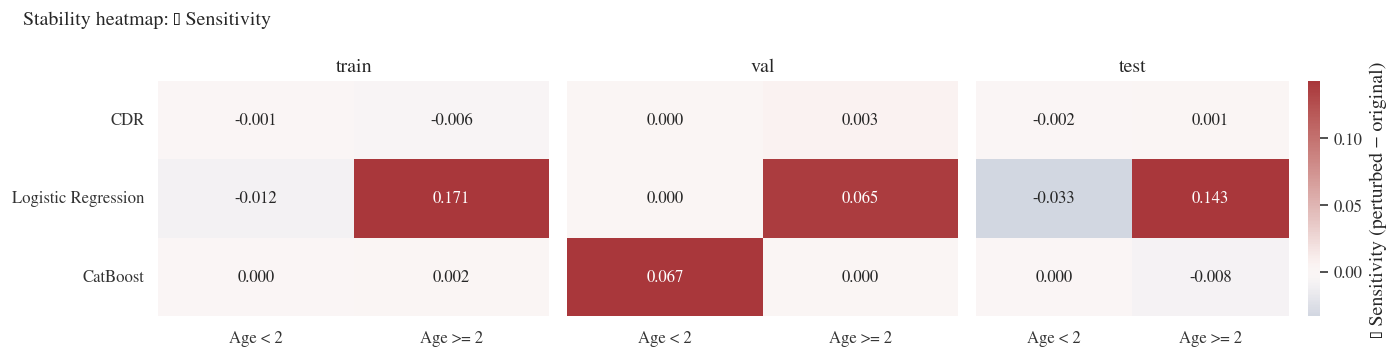

/Users/dannyzhou/anaconda3/envs/stat214/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  fig.canvas.draw()
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_34798/1597153243.py:24: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  plt.tight_layout()
/Users/dannyzhou/anaconda3/envs/stat214/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  fig.canvas.print_figure(bytes_io, **kw)


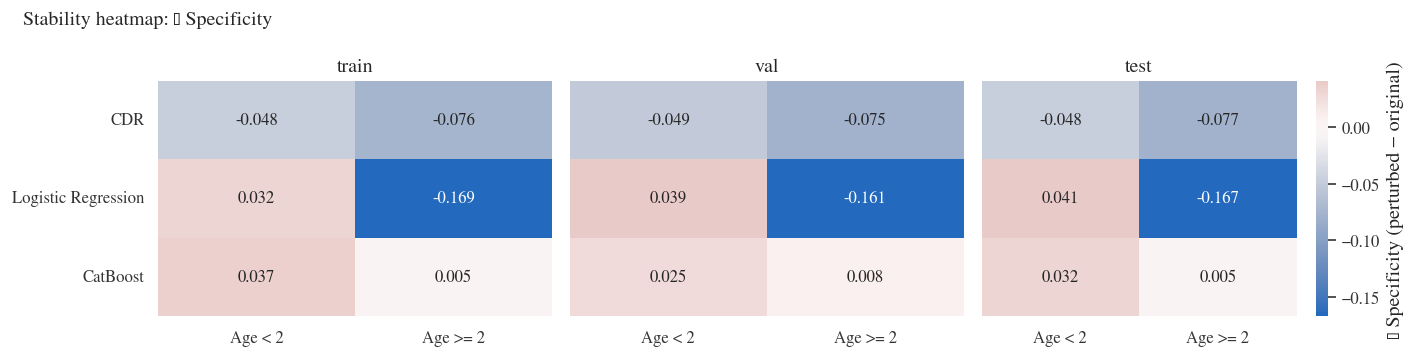

/Users/dannyzhou/anaconda3/envs/stat214/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  fig.canvas.draw()
/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_34798/1597153243.py:24: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  plt.tight_layout()
/Users/dannyzhou/anaconda3/envs/stat214/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times.
  fig.canvas.print_figure(bytes_io, **kw)


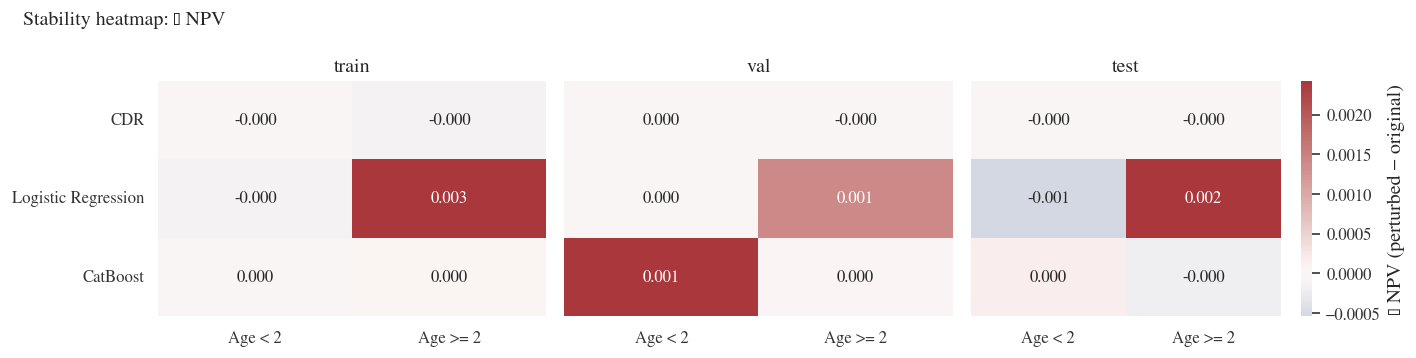

In [42]:
d = delta_full.reset_index()

for metric in ["Sensitivity", "Specificity", "NPV"]:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

    for i, split in enumerate(["train", "val", "test"]):
        ax = axes[i]
        mat = (
            d.query("split == @split")
             .pivot_table(index="model", columns="age_group", values=metric)
             .reindex(index=["CDR", "Logistic Regression", "CatBoost"])
        )

        sns.heatmap(
            mat, ax=ax, annot=True, fmt=".3f",
            cmap="vlag", center=0, cbar=(i==2),
            cbar_kws={"label": f"Δ {metric} (perturbed − original)"}
        )
        ax.set_title(split)
        ax.set_xlabel("")
        ax.set_ylabel("")

    fig.suptitle(f"Stability heatmap: Δ {metric}", x=0.02, ha="left", weight="bold")
    plt.tight_layout()
    plt.show()